In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

In [2]:
from src.utils import load_and_vectorize_data, train_model, translate_sentence, translate_and_visualize
from src.LSTMModel import LSTMModel
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [3]:
enc_in_pt, dec_in_pt, dec_tar_pt, src_vectorizer, trg_vectorizer, max_src_len, max_trg_len = load_and_vectorize_data()

Vectorization Ready. English Vocab: 3355, French Vocab: 7801
Max Source Length: 5, Max Target Length: 12


In [ ]:
model = LSTMModel(src_vectorizer, trg_vectorizer)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
# Create the PyTorch Dataset and DataLoader
batch_size = 64
dataset = TensorDataset(enc_in_pt, dec_in_pt, dec_tar_pt)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [6]:
# Keras usually uses 0 for padding index
pad_idx = 0 
if '' in trg_vectorizer.word_to_index:
    pad_idx = trg_vectorizer.word_to_index['']

train_model(model, train_loader, optimizer, nn.CrossEntropyLoss(ignore_index=pad_idx), num_epochs=15)

Epoch [1/15] | Loss: 5.2091
Epoch [2/15] | Loss: 4.0236
Epoch [3/15] | Loss: 3.4859
Epoch [4/15] | Loss: 3.0889
Epoch [5/15] | Loss: 2.7652
Epoch [6/15] | Loss: 2.4835
Epoch [7/15] | Loss: 2.2391
Epoch [8/15] | Loss: 2.0245
Epoch [9/15] | Loss: 1.8334
Epoch [10/15] | Loss: 1.6621
Epoch [11/15] | Loss: 1.5079
Epoch [12/15] | Loss: 1.3691
Epoch [13/15] | Loss: 1.2426
Epoch [14/15] | Loss: 1.1309
Epoch [15/15] | Loss: 1.0304


In [9]:
test_sentences = [
    "I don't like you.",
    "He is a good boy.",
    "Run!",
    "I am very hungry."]

print("\n--- Translation Test ---")
for eng_text in test_sentences:
    fra_translation = translate_sentence(
        model=model,
        sentence=eng_text,
        src_vectorizer=src_vectorizer,
        trg_vectorizer=trg_vectorizer,
    )
    print(f"English: {eng_text}")
    print(f"French:  {fra_translation}\n")


--- Translation Test ---
English: I don't like you.
French:  je ne vous le fais pas

English: He is a good boy.
French:  c'est un livre

English: Run!
French:  fuyez

English: I am very hungry.
French:  j'ai faim



English Input: He is a good boy.
French Output: c'est un livre


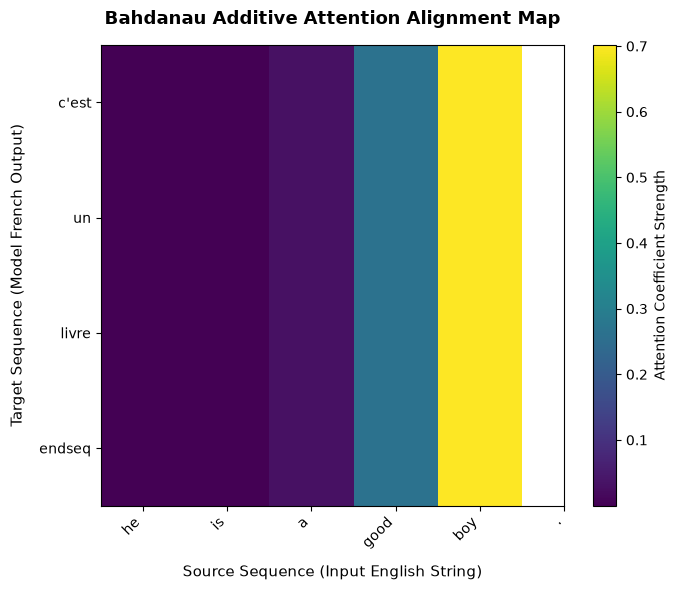

In [8]:
# Ensure your model is trained first, then run:
import torch
input_phrase = "He is a good boy."

translate_and_visualize(
    model=model,
    sentence=input_phrase,
    src_vectorizer=src_vectorizer,
    trg_vectorizer=trg_vectorizer
)

## Conclusion
The results are actually very good. It catches the first till the third lines accurate and the feel of the fourth line wa salso similary although not correct.